# Run an initial LLOWFSC calibration assuming the DM flat command is applied and we are well aligned to the vortex mask. 

In [1]:

import numpy as np
import astropy.units as u
from datetime import datetime
today = int(datetime.today().strftime('%Y%m%d'))
from importlib import reload
from astropy.io import fits
import copy
import time
from datetime import timezone 
from pathlib import Path

import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm, Normalize, CenteredNorm
from matplotlib.patches import Circle, Rectangle
from matplotlib.gridspec import GridSpec

import lina
from lina.math_module import xp, xcipy, ensure_np_array
from lina import utils, coro_utils, scoob_utils
from lina import llowfsc, rt_utils, dm

from magpyx.utils import ImageStream
import purepyindi
from purepyindi import INDIClient
import purepyindi2
from purepyindi2 import IndiClient

client0 = INDIClient('localhost', 7624)
client0.start()
client = IndiClient()
client.connect()
client.get_properties()

def restart_clients():
    client0 = INDIClient('localhost', 7624)
    client0.start()

    client = IndiClient()
    client.connect()
    client.get_properties()

data_path = Path(f'../data/{today}-llowfsc')
utils.make_dir(data_path)


/opt/conda/envs/km310gpu/lib/python3.10/site-packages/cupyx/jit/_interface.py:173: FutureWarning: cupyx.jit.rawkernel is experimental. The interface can change in the future.
  cupy._util.experimental('cupyx.jit.rawkernel')


Directory '../data/20260616-llowfsc' already exists.


INFO:purepyindi2.transports:Connected to localhost:7624


# Connect to the SHMIM streams.

In [2]:
reload(scoob_utils)

cam_channel = 'nsv455'

scoob_utils.set_cam_exp_time(0.000250, client0, cam_name=cam_channel)

Set the nsv455 exposure time to 2.50e-04s


In [3]:
scoob_utils.set_cam_gain(0, client0, cam_name=cam_channel)


Set the nsv455 gain setting to 0.0


In [4]:
scoob_utils.set_cam_blacklevel(50, client0, cam_name=cam_channel)

Set the nsv455 blacklevel to 50.0


In [5]:
reload(scoob_utils)
scoob_utils.set_fiber_atten(0, client0)

Set the fiber attenuation to 0.0


In [ ]:
reload(scoob_utils)
scoob_utils.home_block(client0, delay=2.0)

In [ ]:
scoob_utils.move_block_out(client0)

In [16]:
reload(scoob_utils)
scoob_utils.move_psf(-1, 0, client0)

In [11]:
reload(scoob_utils)
scoob_utils.move_psf(0, -1, client0)

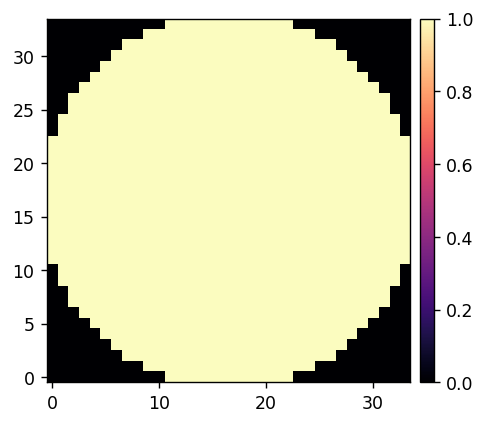

In [17]:
CAMLO_STREAM = ImageStream('nsv455')

DM_STREAMS = []
for i in range(1,11):
    DM_STREAMS.append(ImageStream(f'dm00disp{i:02}'))

rt_utils.create_shmim('llowfsc_zpo', (CAMLO_STREAM.shape[0], CAMLO_STREAM.shape[1]))
ZPO_STREAM = ImageStream('llowfsc_zpo')

rt_utils.create_shmim('llowfsc_gains', (10, 1))
GAINS_STREAM = ImageStream('llowfsc_gains')
rt_utils.write(GAINS_STREAM, np.array(2*[0.8] + 8*[0.05]))

Ncamlo = CAMLO_STREAM.shape[0]
Nact = DM_STREAMS[0].shape[0]

dm_mask = dm.create_mask(Nact=Nact, return_np=1)
utils.imshow(
    [dm_mask]
)

In [18]:
def take_im_fun(
        CAMLO_STREAM,
        NFRAMES=1,
    ):
    camlo_im = np.mean(CAMLO_STREAM.grab_many(NFRAMES), axis=0)
    # camlo_im = np.mean(CAMLO_STREAM.grab_many(NFRAMES), axis=0) if NFRAMES>1 else CAMLO_STREAM.grab_after(1,0)[0]
    return camlo_im

take_im_params = {
    'CAMLO_STREAM':CAMLO_STREAM,
    'NFRAMES':1,
}

def set_dm_fun(
        command,
        DM_STREAM,
    ):

    DM_STREAM.write(1e6*ensure_np_array(command))

set_dm_params = {
    'DM_STREAM':ImageStream('dm00disp02'),
}

def get_dm_fun(
        DM_STREAM,
    ):

    return 1e-6*DM_STREAM.grab_latest()


get_dm_params = {
    'DM_STREAM':ImageStream('dm00disp02'),
}

def get_gains():
    return GAINS_STREAM.grab_latest()[0]

def get_zpo(ZPO_STREAM):
    return ZPO_STREAM.grab_latest()

get_zpo_params = {
    'ZPO_STREAM':ZPO_STREAM,
}

# Obtain a reference dark image for the camera settings that will be used during the duration of LLOWFSC.

In [42]:
scoob_utils.move_block_in(client0)

Saved data to:  ../data/20260616-llowfsc/camlo_dark_0.000250s_0gain_2.fits


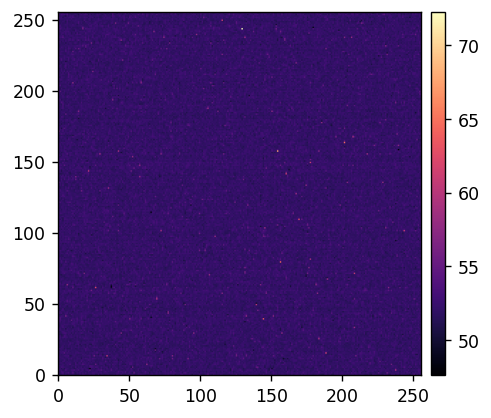

In [45]:

exp_time = scoob_utils.get_cam_exp_time(client0, cam_channel)
gain = scoob_utils.get_cam_gain(client0, cam_channel)

take_im_params.update({
    'NFRAMES':200,
})
camlo_dark = take_im_fun(**take_im_params)
utils.save_fits(data_path/f'camlo_dark_{exp_time:.6f}s_{gain:.0f}gain_2.fits', camlo_dark)

# camlo_dark = ensure_np_array(utils.load_fits(data_path/f'camlo_dark_{exp_time:.6f}s_{gain:.0f}gain.fits'))

utils.imshow([camlo_dark])

In [46]:
scoob_utils.move_block_out(client0)

# Obtain the reference image.

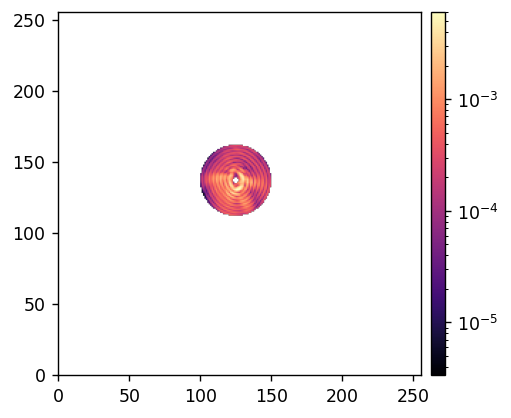

In [23]:
reload(llowfsc)

irad = 2
orad = 25
wfs_mask = utils.create_annular_mask(
    CAMLO_STREAM.shape[0], 
    irad, 
    orad, 
    1,
    edge=None, 
    centering='even',
    x_shift=-3,
    y_shift=9,
    return_np=1,
)

take_im_params.update({
    'NFRAMES':80,
})

ref_im, flux_norm_coeff = llowfsc.acquire_ref(
    take_im_fun,
    take_im_params,
    wfs_mask,
    dark_im=camlo_dark,
    flux_norm=True,
)

utils.imshow(
    [ref_im],
    norms=[LogNorm()] 
)


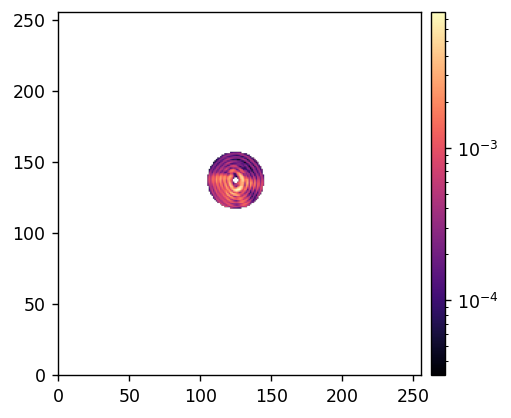

In [72]:
reload(llowfsc)

irad = 2
orad = 20
wfs_mask = utils.create_annular_mask(
    CAMLO_STREAM.shape[0], 
    irad, 
    orad, 
    1,
    edge=None, 
    centering='even',
    x_shift=-3,
    y_shift=9,
    return_np=1,
)

take_im_params.update({
    'NFRAMES':80,
})

ref_im_2, flux_norm_coeff_2 = llowfsc.acquire_ref(
    take_im_fun,
    take_im_params,
    wfs_mask,
    dark_im=camlo_dark,
    flux_norm=True,
)

utils.imshow(
    [ref_im_2],
    norms=[LogNorm()] 
)


# Calibrate for the set of Zernike modes that we want to control.

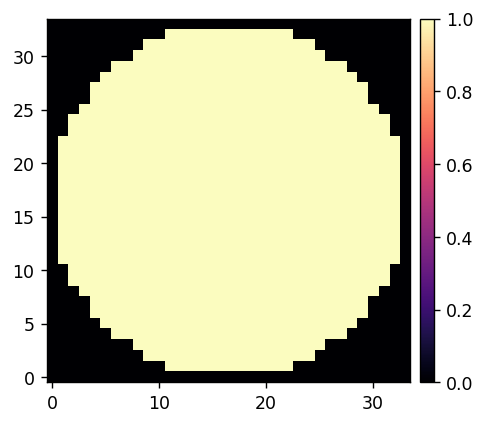

Calibrated mode 1/10 in 0.988s

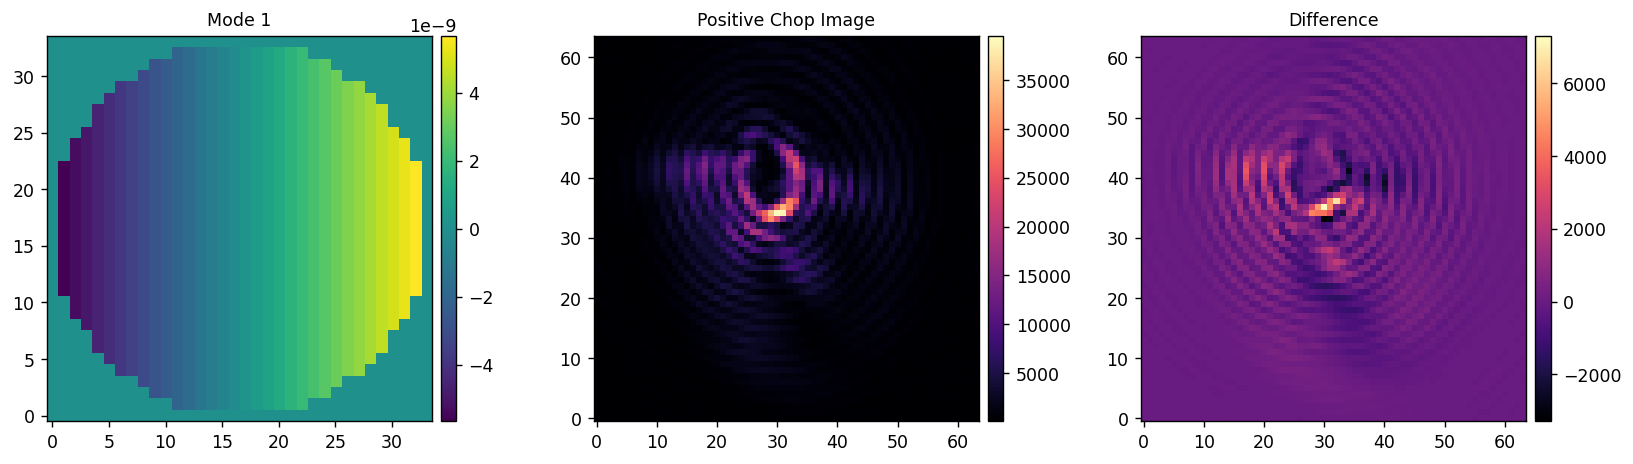

Calibrated mode 2/10 in 2.608s

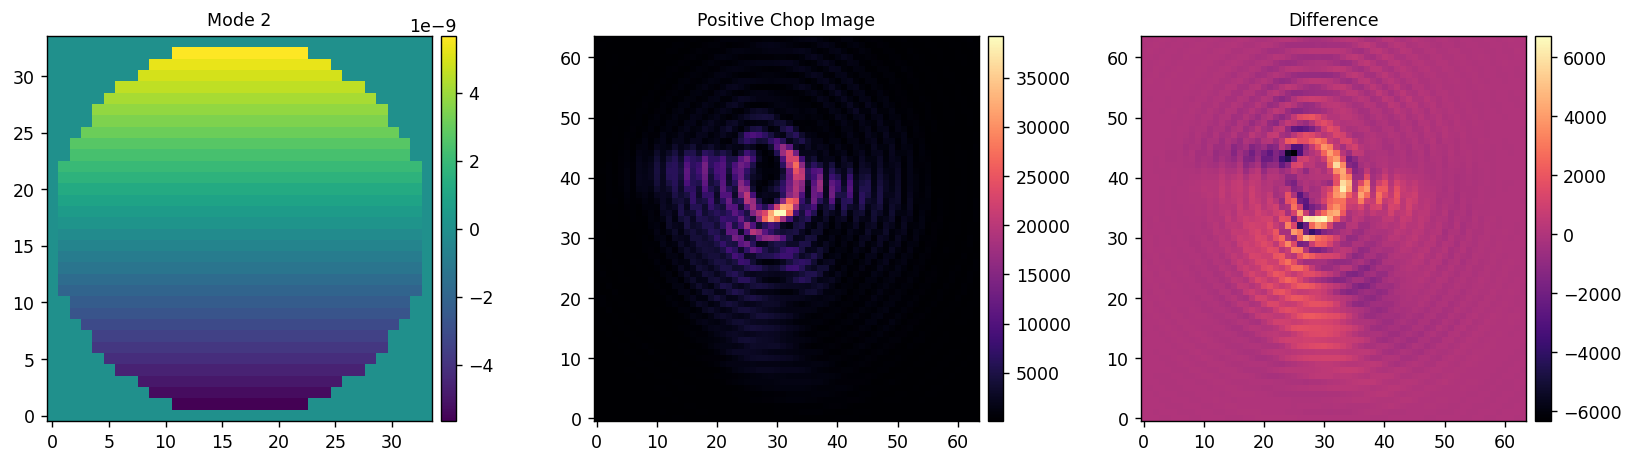

Calibrated mode 3/10 in 4.289s

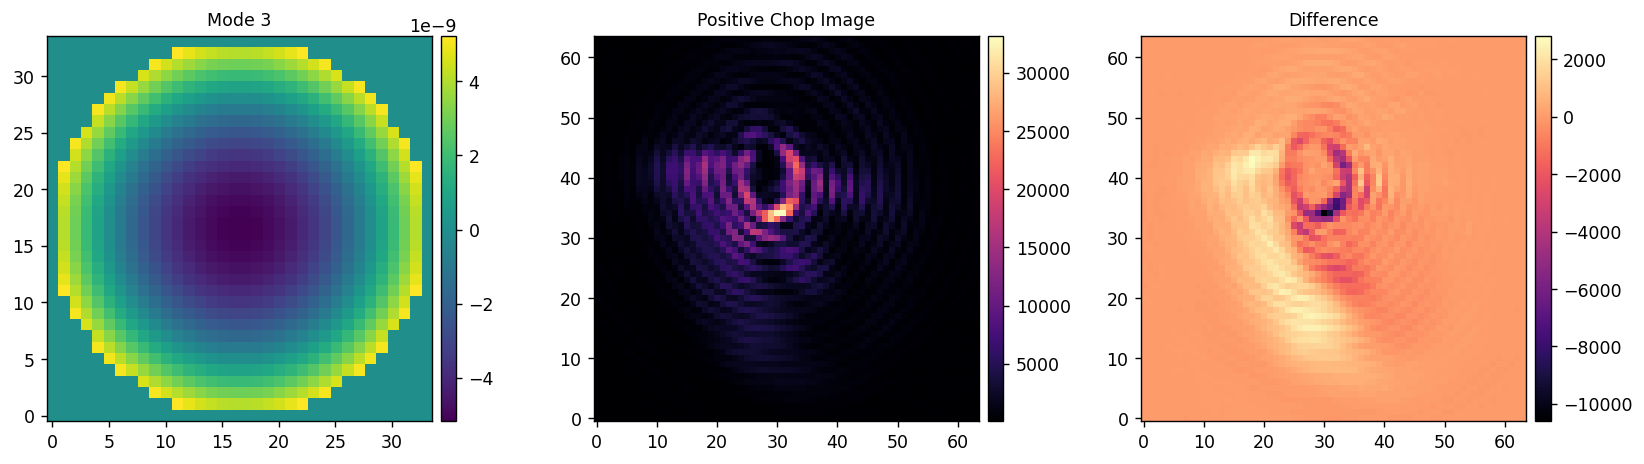

Calibrated mode 4/10 in 6.010s

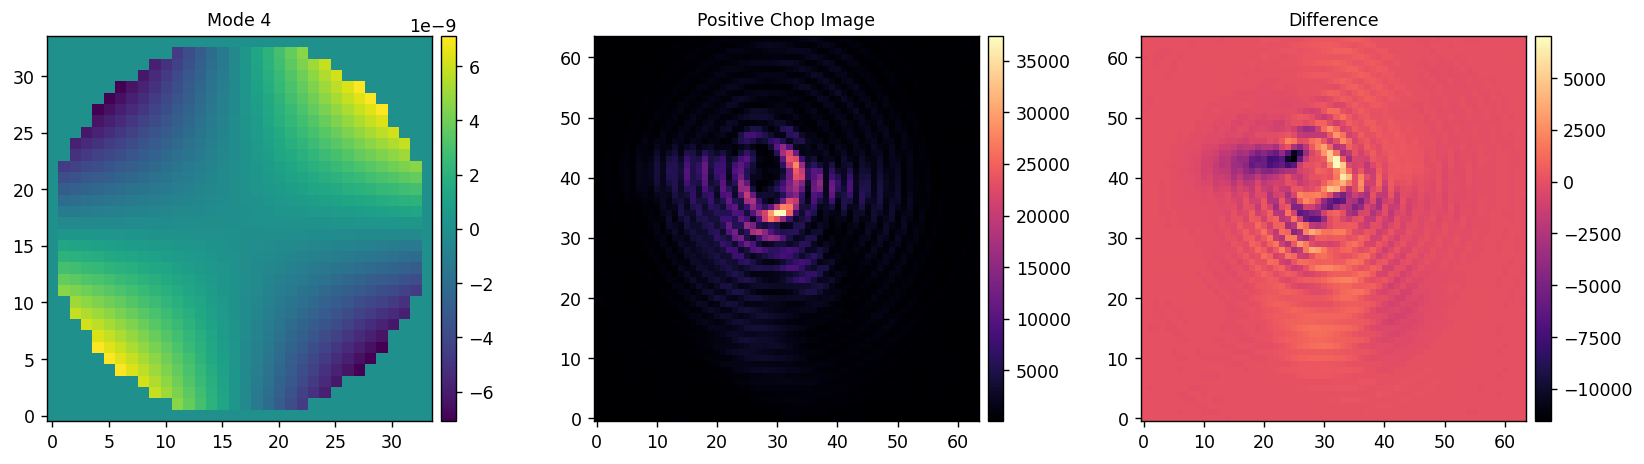

Calibrated mode 5/10 in 8.001s

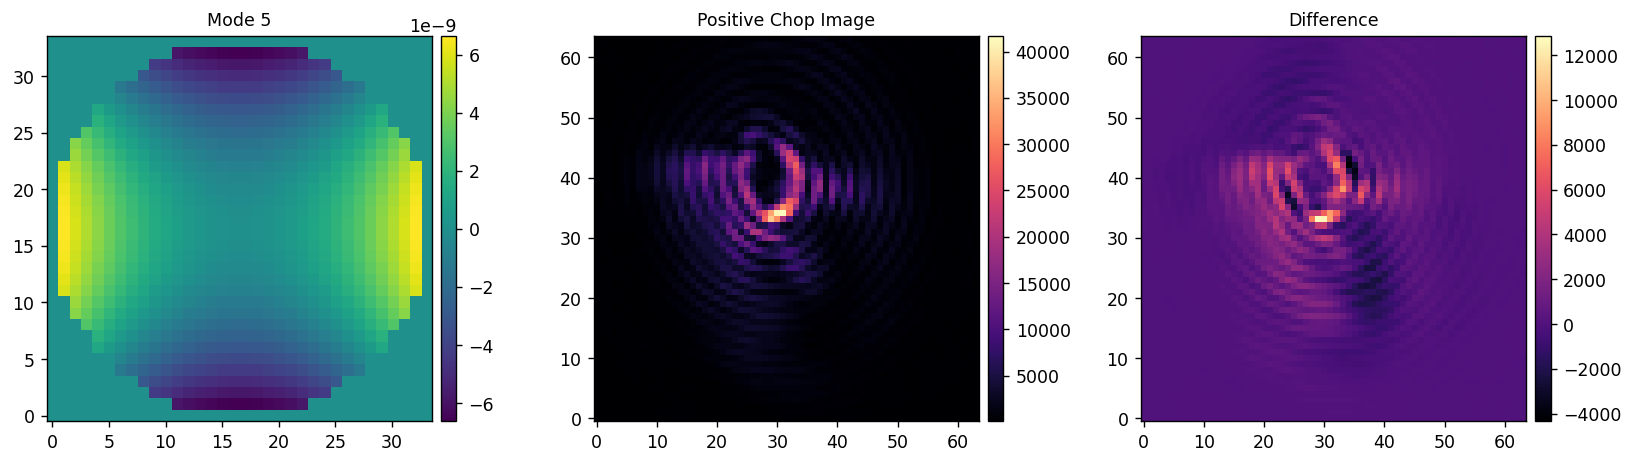

Calibrated mode 6/10 in 9.620s

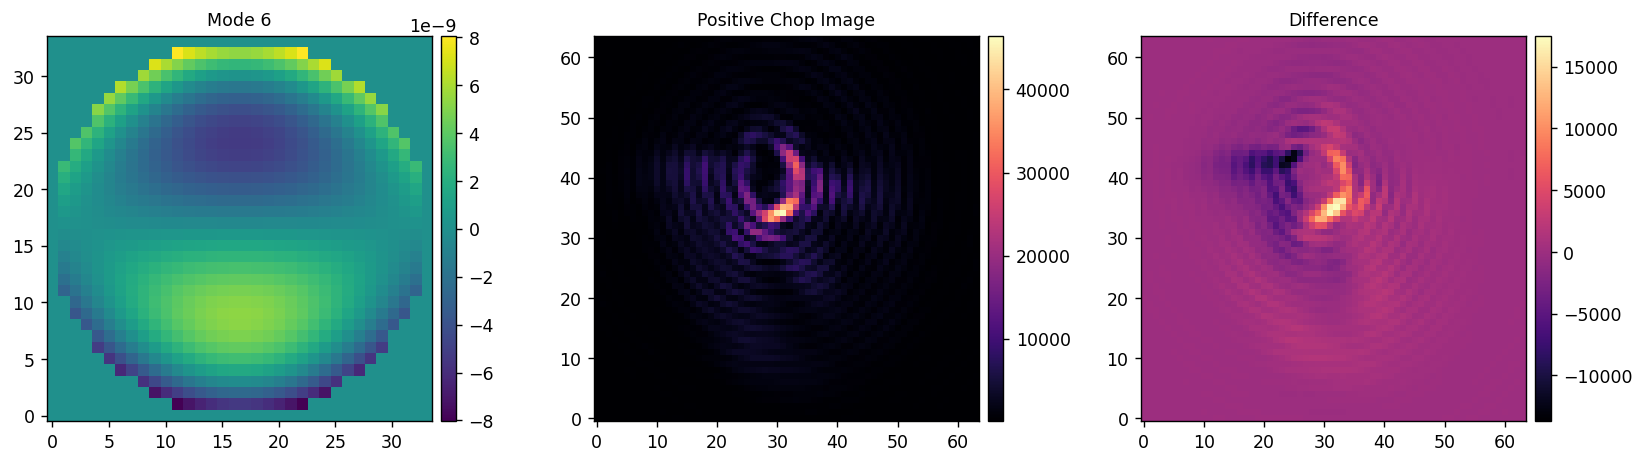

Calibrated mode 7/10 in 11.217s

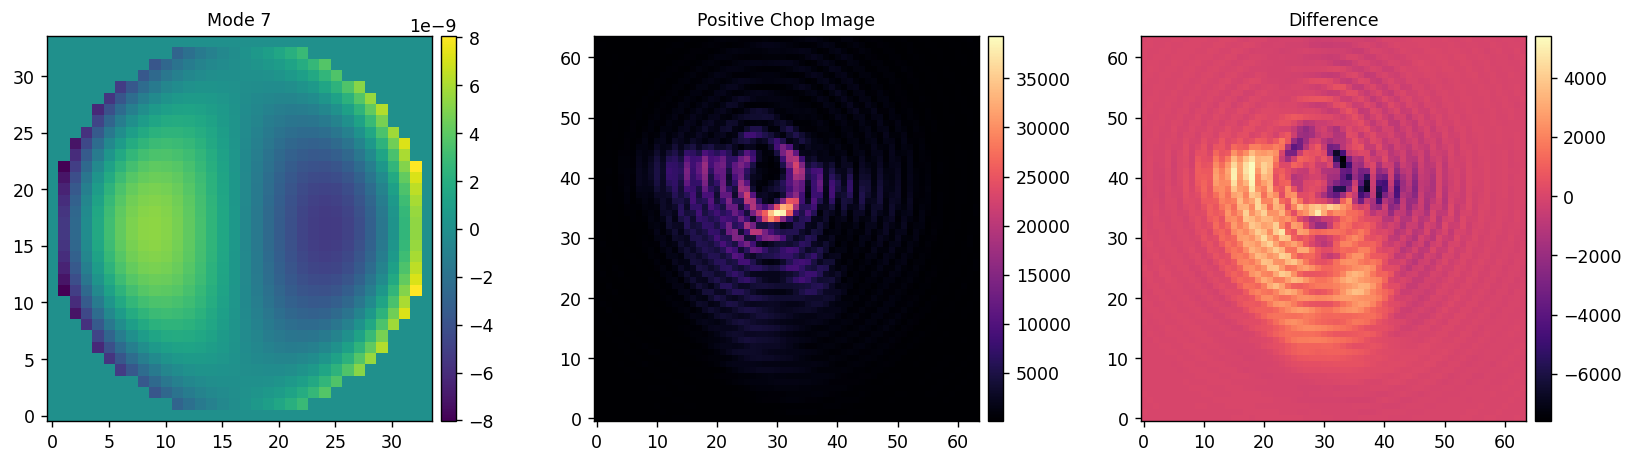

Calibrated mode 8/10 in 12.842s

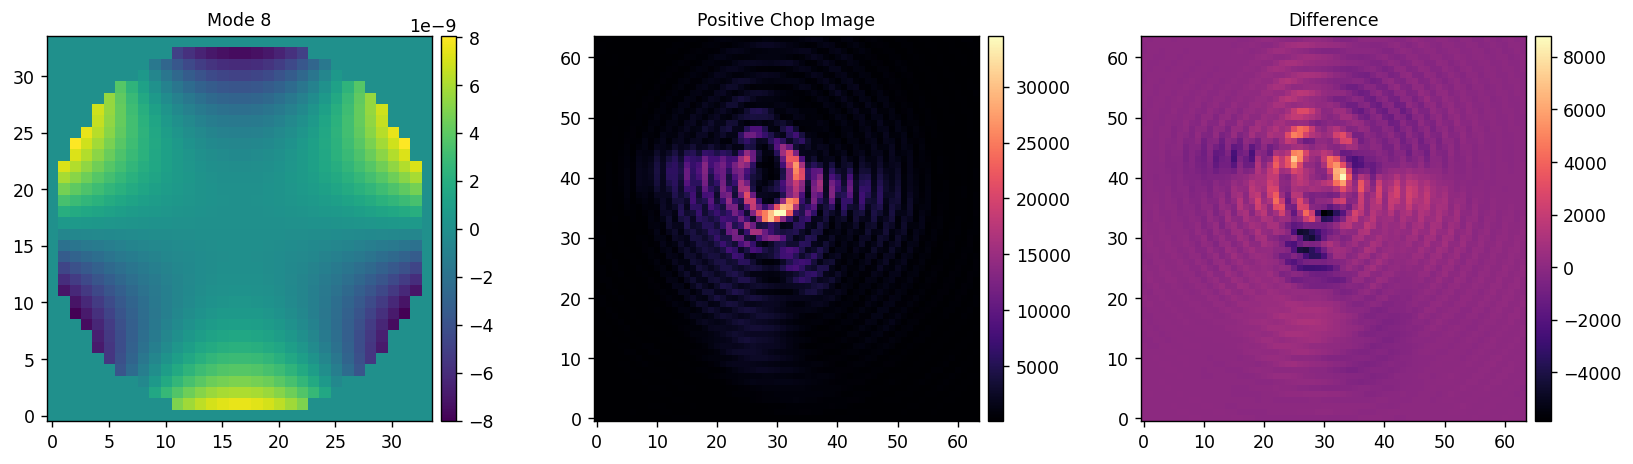

Calibrated mode 9/10 in 14.547s

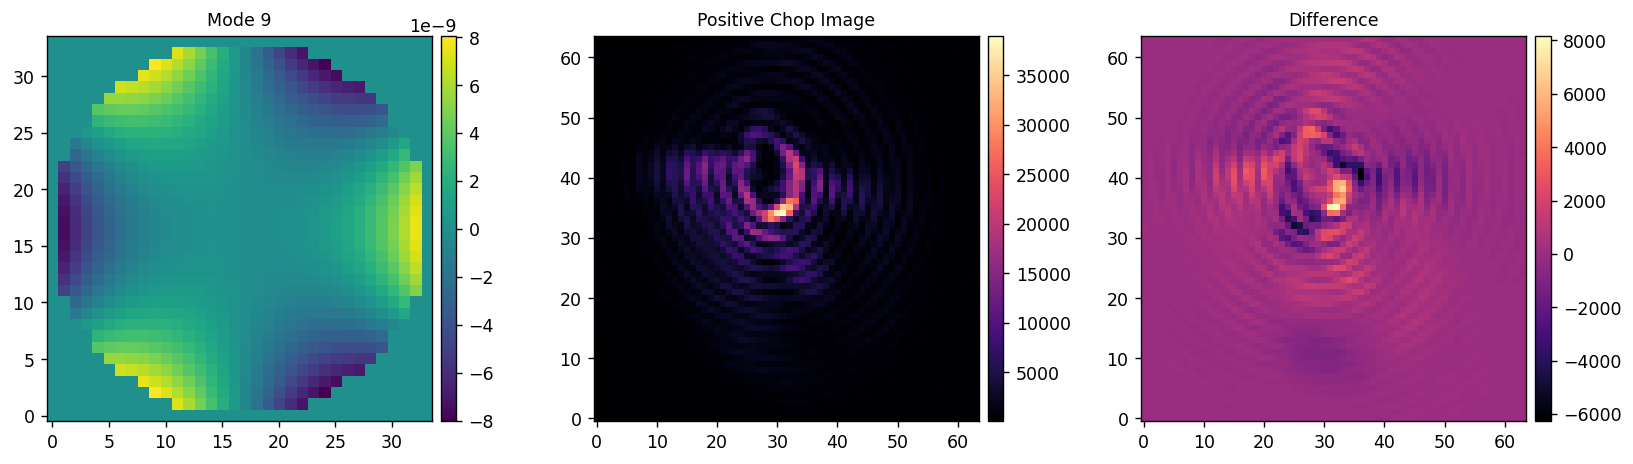

Calibrated mode 10/10 in 16.343s

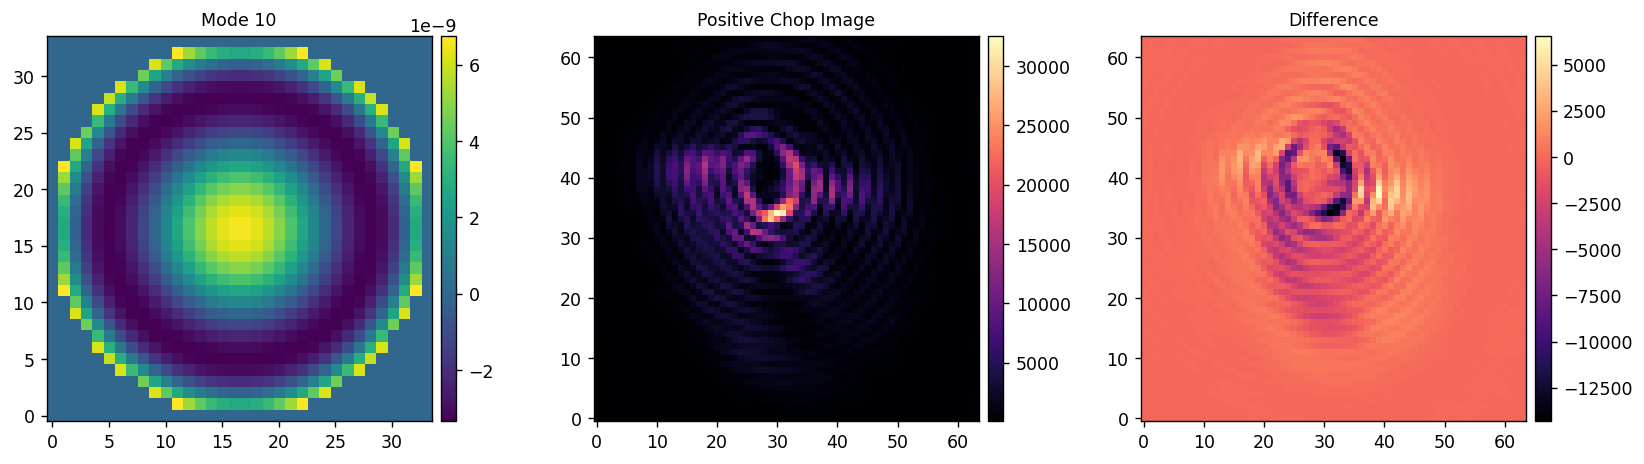

In [73]:
reload(llowfsc)
reload(dm)
reload(utils)

Nmodes = 10

dm_zer_mask = utils.pad_or_crop(dm.create_mask(Nact=Nact - 2, return_np=1), DM_STREAMS[0].shape[0])
utils.imshow(
    [dm_zer_mask],
)
dm_zernike_modes = dm.create_zernike_modes(dm_zer_mask, nmodes=Nmodes, remove_modes=1, return_np=1)
# utils.imshow([dm_zernike_modes[0], dm_zernike_modes[3], dm_zernike_modes[-1]], cmaps=3*['viridis'])

take_im_params.update({
    'NFRAMES':20,
})

zer_rm, zer_response_cube = llowfsc.calibrate_dm_modes(
    take_im_fun,
    take_im_params,
    set_dm_fun,
    set_dm_params,
    dm_zernike_modes, 
    wfs_mask, 
    amp=3e-9, 
    flux_norm_coeff=flux_norm_coeff,
    # include_factor_2=True, 
    plot=True,
    Nplot=64,
)


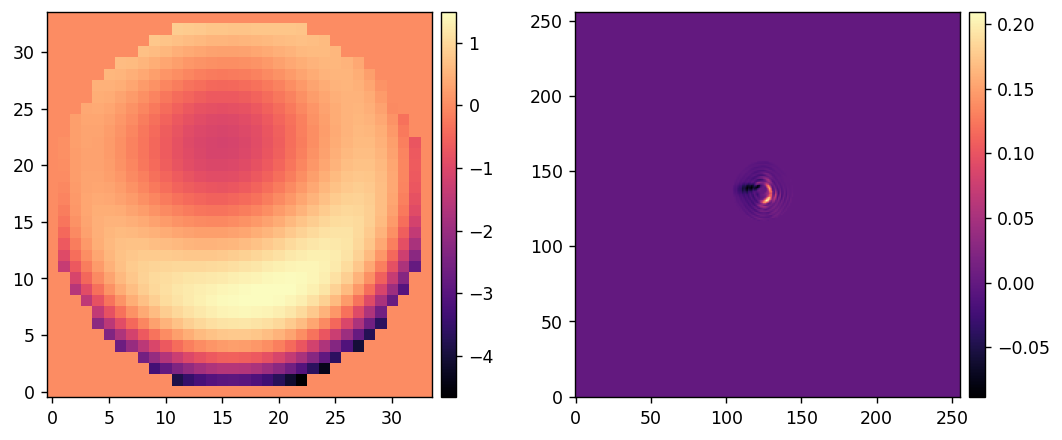

In [74]:
reload(utils)
P, U, s, Vt = utils.tikhonov_inverse(zer_rm, 0, return_all=1, return_np=1)

dm_modes = np.zeros((Nmodes, Nact, Nact))
wfs_modes = np.zeros((Nmodes, Ncamlo, Ncamlo))
for i in range(Nmodes):
    dm_modes[i, dm_mask] = Vt.dot(dm_zernike_modes[:, dm_mask])[i]
    # dm_modes[i, dm_mask] = Vt.T.dot(dm_zernike_modes[:, dm_mask])[i]
    wfs_modes[i, wfs_mask] = U.T[i] 

# dm_modes = Vt.dot(dm_zernike_modes[:, dm_mask])
# wfs_modes = U.T

# dm_modes.shape

i = 0
utils.imshow(
    [dm_modes[i], wfs_modes[i]]
)

# Start the LLOWFSC process

In [75]:
reload(rt_utils)

take_im_params.update({
    'NFRAMES':1,
})

llowfsc_proc = rt_utils.ContinuousProcess(
    llowfsc.run,
    args=[
        take_im_fun,
        take_im_params,
        set_dm_fun,
        set_dm_params,
        get_dm_fun,
        get_dm_params,
        get_gains,
        ref_im_2,
        P,
        dm_zernike_modes,
        wfs_mask,
    ],
    kwargs={
        'dark_im':camlo_dark,
        'get_zpo':get_zpo,
        'get_zpo_params':get_zpo_params,
    },
)

In [76]:
llowfsc_proc.start()

UNNAMED process started. PID = 1961935


In [70]:
llowfsc_proc.stop()
set_dm_fun(np.zeros_like(dm_mask), **set_dm_params)

UNNAMED process terminated.


In [71]:
rt_utils.write(GAINS_STREAM, np.array(2*[0.8] + 8*[0.05]))

In [23]:
ZPO_STREAM.write(np.zeros_like(ref_im))

# Setup the ZPO process

In [77]:
def compute_zpo(
        DM_STREAMS,
        dm_mask,
        wfs_mask,
        response_matrix,
        dm_modal_matrix,
        ZPO_STREAM,
    ):
    zpo = np.zeros((wfs_mask.shape[0], wfs_mask.shape[1]))
    for i in range(len(DM_STREAMS)):
        zpo[wfs_mask] += response_matrix.dot( dm_modal_matrix.dot(1e-6*DM_STREAMS[i].grab_latest()[dm_mask]) )

    ZPO_STREAM.write(zpo)

zpo_params = {
    'DM_STREAMS':DM_STREAMS[2:5],
    # 'DM_STREAMS':[DM_STREAMS[1]],
    'dm_mask':dm_mask,
    'wfs_mask':wfs_mask,
    'response_matrix':zer_rm, 'dm_modal_matrix':dm_zernike_modes[:, dm_mask]/952 ,
    # 'response_matrix':had_rm, 'dm_modal_matrix':dm_had_modes[:, dm_mask]/1024,
    'ZPO_STREAM':ZPO_STREAM,
}


In [26]:
%%timeit -n 1000
zpo = compute_zpo(**zpo_params)

376 μs ± 21.5 μs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)


In [78]:
reload(rt_utils)
zpo_freq = 500

zpo_process = rt_utils.TimedThread(
    1/zpo_freq,
    compute_zpo,
    kwargs=zpo_params,
)

In [79]:
zpo_process.start()

In [53]:
zpo_process.cancel()

### Test if ZPO is working by injecting some Zernikes. LLOWFSC should NOT correct what you inject if ZPO is working correctly. 

In [34]:
set_dm_fun(3e-9 * dm_zernike_modes[5], DM_STREAMS[2])

In [35]:
set_dm_fun(0e-9 * dm_zernike_modes[5], DM_STREAMS[2])